# Spam or Ham (project 1)

## 1- Introduction with the Bernoulli model


We say that a random variables $X \in \{0, 1\}$ follows a Bernoulli distribution of parameter $\theta$ if $\mathbb{P}(X = 1) = \theta$ and $\mathbb{P}(X = 0) = 1 − \theta$.


1.  Show that we can write the probability distribution of $X$ in a compact form as :
$$
\mathbb{P}(X = x) = \theta^{x} (1 − \theta)^{1−x}
$$

2. Suppose now that we have a set of n independent variables $x_1,...,x_n$. If we note $n_1 = \sum_{i=1}^n \mathbb{1}_{\{x_i=1\}}$ and $n_0 = n − n_1$, show that :
$$
\mathbb{P}(x_1,\ldots,x_n \mid \theta)=\theta^{n_1} (1−\theta)^{n_0}
$$

3. Show that the maximum likelihood estimator is $\hat{\theta}_{ML} = \frac{n_1}{n}$

4. A conjugate prior for the Bernoulli distribution is the Beta distribution.
$$
Beta(\theta \mid a, b) \propto \theta^{a−1} (1 − \theta)^{b−1}
$$
The Beta distribution has the following properties for its expectation and mode (for more details you can look in one of the books like the Bishop):
$$
\mathbb{E}(\theta) = \frac{a}{a+b} \text{, mode}(\theta) = \frac{a-1}{a+b-2}
$$

Show that with a $Beta(a,b)$ prior the posterior distribution
$\mathbb{P}(\theta \mid x_1,\ldots, x_n)$
is proportional to $\theta^{n_1+a-1} \cdot (1 − \theta)^{n_0+b-1}$

5. (Those two questions are optional, you can also simply use the result in the following)

   a. Show that the maximum a posteriori _mode_ estimate is in the form $\bar{\theta}_{MAP} = \frac{n_1+a-1}{n+a+b-2}$

   b. Show that the maximum a posteriori _mean_ estimate is in the form $\hat{\theta}_{MAP} = \mathbb{E}(\theta \mid x_1,\ldots, x_n) =
\int_{\theta =0}^1 \mathbb{P}(\theta \mid x_1\ldots x_n) d\theta  = \frac{n_1+a}{n+a+b}$


## _write your answers to the questions here (you can also provide a scanned pdf of your answers with the notebook)_

## Spam classifier

The goal of this small project is to use a Naive bayes classifier to build a spam filter. To build our filter, we will use a dataset of 5,572 SMS messages put together by Tiago A. Almeida and José María Gómez Hidalgo. 
The dataset and the article describing the dataset are in the whiteboard directory together with this notebook. Of note, the SMS messages have already been processed for ease of use: all punctuation marks have been removed and the text has been transformed into lowercase. It is also common practice to remove any stop words such as `a`, `as`, `the` and to perform stemming (reduce words to their base form, such as stripping  the final `s*` in plural words, or the `*ing` from verbs (e.g., running becomes run)). For the sake of simplicity, we did not do that in this exercise.

We will use a bag of word model:
 - We construct a corpus of the possible words $\mathcal{D} = \{w_1, \ldots , w_d\}$.
 - Each document is described by a vector of binary values $(x^{(1)}, \ldots , x^{(d)})$ where $x^{(i)} = 1$ if $w_i$ occurs in the document and $0$ otherwise.

The classification task is to predict for an SMS message if it is a _spam_ or a _ham_ (e.g. non-spam).

Our data is thus $\mathbf{x} = (x^{(1)},\ldots, x^{(d)})$, $x^{(i)} \in \{0,1\}$ and $y \in \{s,h\}$
We hypothesise that the values $x^{(i)}$ are drawn according to a Bernoulli distribution whose parameter depends on the class:
$$
\mathbb{P}(x^{(i)} \mid y = s) = \theta_{i,s}^{x^{(i)}} \cdot (1-\theta_{i,s})^{1-x^{(i)}}
$$
and 
$$
\mathbb{P}(x^{(i)} \mid y = h) = \theta_{i,h}^{x^{(i)}} \cdot (1-\theta_{i,h})^{1-x^{(i)}}
$$
As we will use a naive Bayes classifier, the occurences of the different words are independent from each other.
\begin{align}
\mathbb{P}(\mathbf{x} \mid y = s) & = \prod_{i=1}^{d} \mathbb{P} (x^{(i)} \mid y = s)\\
  & =  \prod_{i=1}^{d} \theta_{i,s}^{x^{(i)}} \cdot (1-\theta_{i,s})^{1-x^{(i)}}
\end{align}


## Importing library and loading dataset

In [1]:
%ls

 Datentr�ger in Laufwerk C: ist Acer
 Volumeseriennummer: 0273-FF60

 Verzeichnis von c:\Users\misog\Documents\FUB_sems\summer26\MachineLearning\02-2-SpamClassifier\02-2-SpamClassifier

25. 04. 2026  10:22    <DIR>          .
25. 04. 2026  10:36    <DIR>          ..
25. 04. 2026  10:22           114�735 ContributionToTheStudyofSpamFiltering.pdf
25. 04. 2026  10:22           477�291 SMSSpamCollection_cleaned.csv
25. 04. 2026  12:55            21�436 Spam_project_subject_2026.ipynb
               3 Datei(en),        613�462 Bytes
               2 Verzeichnis(se), 79�744�970�752 Bytes frei


In [2]:
%matplotlib inline
import numpy as np
from collections import Counter

##Load the dataset (if in the same directory as the notebook)
sms_data = np.loadtxt("./SMSSpamCollection_cleaned.csv", delimiter="\t", skiprows=1, dtype=str,encoding='utf-8')

## create test data set for checkpointing
checkpoint_data = np.array([['spam', 'dear researcher submit manuscript money'], 
          ['ham','dear friend meet beer'],
          ['ham', 'dear friend meet you']], dtype=str)

In [3]:
##Check the dataset
sms_data

array([['ham',
        'go until jurong point  crazy   available only in bugis n great world la e buffet    cine there got amore wat   '],
       ['ham', 'ok lar    joking wif u oni   '],
       ['spam',
        'free entry in 2 a wkly comp to win fa cup final tkts 21st may 2005  text fa to 87121 to receive entry question std txt rate t c s apply 08452810075over18 s'],
       ...,
       ['ham',
        'pity    was in mood for that  so   any other suggestions '],
       ['ham',
        'the guy did some bitching but i acted like i d be interested in buying something else next week and he gave it to us for free'],
       ['ham', 'rofl  its true to its name']], dtype='<U910')

In [4]:
##Check the size of the dataset
num_messages = sms_data.shape[0]
print(num_messages)

##third message is a...
print("Third message is a:", sms_data[2][0])
##dividing the third message into words
print(sms_data[2][1].split())

5572
Third message is a: spam
['free', 'entry', 'in', '2', 'a', 'wkly', 'comp', 'to', 'win', 'fa', 'cup', 'final', 'tkts', '21st', 'may', '2005', 'text', 'fa', 'to', '87121', 'to', 'receive', 'entry', 'question', 'std', 'txt', 'rate', 't', 'c', 's', 'apply', '08452810075over18', 's']


## 2 - Construction of the Corpus

Construct the corpus $\mathcal{D}$ of all words in the dataset. The corpus will be represented as a hash table where each key is a unique word in the dataset and each value is the row index for that word. 
 - How many unique words are there? 
 - What are the 10 most common words (_e.g._ occuring in the most documents)?
 - Transform the set of messages in the form of a binary matrix of word occurrences.
 
 You can evaluate whether your implementation works using the checkpoint_data array. For this dataset the corpus could look as follows :

`{'dear': 0, 'researcher': 1, 'submit': 2, 'manuscript': 3, 'money': 4, 'friend': 5, 'meet': 6, 'beer': 7, 'you': 8}`
(of course you could have other index values for the words). 

The recoding of the checkpoint data will give you the following numpy array:

```
[[1. 1. 1. 1. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 1. 1. 1. 0.]
 [1. 0. 0. 0. 0. 1. 1. 0. 1.]]
```

In [5]:
def construct_corpus(data):
    """
    np.array[str, str] -> dict[str:int]
    
    from a 2D array of str, return a dict
    """
    corpus = {}
    for msg in data:
        for word in msg[1].split():
            if word not in corpus:
                corpus[word] = len(corpus.keys())
    return corpus

##test
checkpoint_corpus = construct_corpus(checkpoint_data)
checkpoint_corpus


{'dear': 0,
 'researcher': 1,
 'submit': 2,
 'manuscript': 3,
 'money': 4,
 'friend': 5,
 'meet': 6,
 'beer': 7,
 'you': 8}

In [6]:

    
def recode_messages(data, corpus):
    """
    np.array[str, str] * dict[str:int] -> np.array[int, int]
    
    returns the binary matrix encoding 
    """
    bin_data = np.zeros((len(data),len(corpus)))
    ##Your code here
    for msg_idx, msg in enumerate(data):
        for word_idx, word in enumerate(msg[1].split()):
            bin_data[msg_idx][corpus[word]] = 1

    return bin_data
D = construct_corpus(sms_data)

sms_matrix = recode_messages(sms_data, D)
## Test
checkpoint_matrix = recode_messages(checkpoint_data, checkpoint_corpus)
checkpoint_matrix

array([[1., 1., 1., 1., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 1., 1., 1., 0.],
       [1., 0., 0., 0., 0., 1., 1., 0., 1.]])

## 3 - Construct a training and a testing set and estimation of parameters


To do the evaluation of the model afterward we will split the dataset randomly in two: 
- one dataset for training (80% of the messages) 
- one dataset for testing (20% of the messages).

If you are familiar with it, you can use the `sklearn.model_selection` functions to construct the train and test datasets.


In [42]:

def train_test_split(X, Y, train_percentage=0.8):
    assert X.shape[0] == Y.shape[0]

    number_examples = X.shape[0]
    num_train = int(train_percentage * number_examples)
    ##Your code here
    choose_map = np.random.binomial(1,train_percentage, X.shape[0])
    X_train = X[choose_map==1]
    X_test = X[choose_map==0]
    Y_train = Y[choose_map==1]
    Y_test = Y[choose_map==0]
    
    return X_train, X_test, Y_train, Y_test
    
## Another option is to shuffle indicies and manually cut shuffled list
X_train, X_test, Y_train, Y_test = train_test_split(sms_matrix, sms_data[:,0])

## 4 - Estimation of the model parameters

We will now estimate our model on the training set. This means estimating two types of parameters: the class prior, and the conditional word occurrence probabilities.

1.  Estimate the class prior $\mathbb{P}(c) = \mathbb{P}(y = c), (c = s, h)$
2.  Using the results from section 1, compute the Maximum a posteriori estimator for the $d \times 2$ matrix of parameters (reminder $\theta_{i,j} = \mathbb{P}(x=i \mid y = j)$).
 $$
 \Theta = \left(
 \begin{array}{cc}
 \theta_{1,h}   & \theta_{1,s} \\
 \theta_{2,h} & \theta_{2,s} \\
 \vdots & \vdots \\
 \theta_{d,h} & \theta_{d,s} \\
 \end{array}
 \right).
 $$ You can use as conjugate prior a Beta(1, 1) distribution for instance (then $\theta_{i,c} = \frac{n_{i,c}+1}{N+2}$ where $n_{i,c}$ is the number of documents from the class $c$ where the word $w_i$ is present and $N$ is the total number of documents of that class).

 When applied to the checkpoint data, your $\Theta$ matrix should look like this:

 ```
 # h    s
 [[0.75 0.66666667]  #'dear'
  [0.25 0.66666667]  #'researcher'
  [0.25 0.66666667]  #'submit'
  [0.25 0.66666667]  #'manuscript'
  [0.25 0.66666667]  #'money'
  [0.75 0.33333333]  #'friend'
  [0.75 0.33333333]  #'meet'
  [0.5  0.33333333]  #'beer'
  [0.5  0.33333333]] #'you'
 ```

3. Represent the fitted word occurrence class conditional probabilities $(\theta_{i,h})_{i \in \mathcal{D}}$ and $(\theta_{i,s})_{i \in \mathcal{D}}$. You can represent it as two barplots, like shown in the lecture at the end of the "Naive Bayes for document" part. 


In [8]:
print(checkpoint_data)

[['spam' 'dear researcher submit manuscript money']
 ['ham' 'dear friend meet beer']
 ['ham' 'dear friend meet you']]


In [81]:
## Your code here for class priors
def class_prior(target, classname):

    class_prop = sum(target == classname)/target.shape[0]
    return class_prop

prior_ham = class_prior(Y_train, 'ham')
prior_spam = class_prior(Y_train, 'spam')

print('Prior ham', prior_ham)
print('Prior spam', prior_spam)

Prior ham 0.8640143852551135
Prior spam 0.1359856147448865


In [82]:

def estimate_proportions(data_matrix):
    """
    estimate the matrix theta
    """
    #your code here
    proportion_mx = np.zeros(data_matrix.shape[1])
    for idx in range(data_matrix.shape[1]):
        #print("this is supposed to be column", idx, data_matrix[:, idx])
        prop = (np.sum(data_matrix[:, idx]) + 1) / (data_matrix.shape[0] +2) # Beta(1,1)
        proportion_mx[idx] = prop
    return proportion_mx
    
##
Dico = {'dear': 0, 'researcher':1, 'money': 2, 'friend': 3 }
#sentence 1 dear friend money 
#sentence 2 dear researcher friend
#sentence  friend money money
datam = np.array([[1, 0, 1, 1],[1, 1, 0, 1],[0, 0, 1, 1]], dtype = int)

theta_spam = estimate_proportions(X_train[Y_train=='spam'])
theta_ham = estimate_proportions(X_train[Y_train=='ham'])

ham_idxs = checkpoint_data[:,0] == 'ham'
estimate_proportions(checkpoint_matrix[ham_idxs])

array([0.75, 0.25, 0.25, 0.25, 0.25, 0.75, 0.75, 0.5 , 0.5 ])

In [84]:
def class_log_posterior(data_matrix, prior, theta):

    log_posterior = np.dot(data_matrix, np.log(theta)) + np.dot(1-data_matrix,np.log(1-theta)) + np.log(prior)
    return log_posterior

log_prob_ham = class_log_posterior(X_train, prior_ham, theta_ham)
print("ham log_probs", log_prob_ham, np.exp(log_prob_ham))
log_prob_spam = class_log_posterior(X_train, prior_spam, theta_spam)
print("spam log_probs", log_prob_spam, np.exp(log_prob_spam))

ham log_probs [-115.18380004  -43.90534773 -180.20485826 ...  -57.67837578 -115.66612007
  -37.92062195] [9.46915523e-51 8.55361610e-20 5.47046757e-79 ... 8.92482424e-26
 5.84577790e-51 3.39846761e-17]
spam log_probs [-141.32180225  -73.6419263  -131.28606514 ...  -83.49096467 -149.60811722
  -60.1832712 ] [4.21425791e-62 1.04164029e-32 9.62025003e-58 ... 5.49964626e-37
 1.06174504e-65 7.29016597e-27]


In [86]:
def classify(data_matrix, prior_ham, prior_spam, theta_spam, theta_ham):
    
    log_post_ham = class_log_posterior(data_matrix, prior_ham, theta_ham )
    log_post_spam = class_log_posterior(data_matrix, prior_spam, theta_spam)

    # normalize to ge prob from [0,1]
    M = np.maximum(log_post_ham, log_post_spam)
    norm_post_h = np.exp(log_post_ham-M) / (np.exp(log_post_ham-M) + np.exp(log_post_spam-M))
    return norm_post_h

In [ ]:
probs = classify(X_test, prior_ham, prior_spam, theta_spam, theta_ham)
prediction = ['ham' if p > 0.5 else 'spam' for p in probs]
print('success',np.mean(Y_test==prediction))

success 0.9786286731967943


In [ ]:
def confusion_matrix(X, Y, treshold, prior_ham, prior_spam, theta_spam, theta_ham):
    probs = classify(X, prior_ham, prior_spam, theta_spam, theta_ham)
    prediction = np.array(['ham' if p > treshold else 'spam' for p in probs])
    #print(prediction)
    TP = np.sum((Y == 'spam') & (prediction == 'spam'))
    TN = np.sum((Y == 'ham') & (prediction == 'ham'))
    FP = np.sum((Y == 'ham') & (prediction == 'spam'))
    FN = np.sum((Y == 'spam') & (prediction == 'ham'))
    
    return TP, FP, TN, FN

def ROC(X,Y, treshold):
    TP, FP, TN, FN = confusion_matrix(X,Y, treshold, prior_ham, prior_spam, theta_spam, theta_ham)
    #print(TP, FP, TN, FN)
    sensitivity = TP / (TP + FN)
    specificity = TN / (TN + FP)
    return [1-specificity, sensitivity]

In [48]:
import matplotlib.pyplot as plt

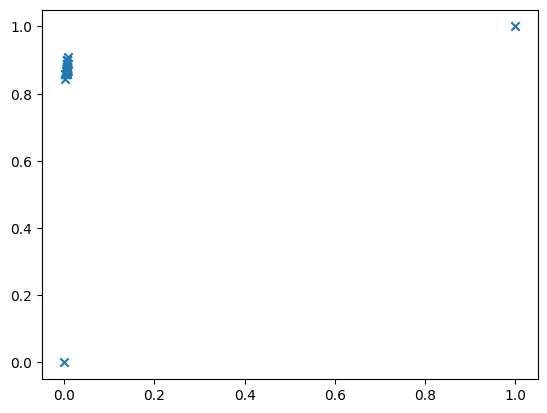

In [106]:
tresholds = np.linspace(0,1,50)
ROCs = [ROC(X_test,Y_test, t) for t in tresholds]
ROCs = np.array(ROCs)
# print(ROCs)
plt.scatter(ROCs[:,0], ROCs[:,1], marker='x')
plt.show()

## 4 - Message classification


4. Classify the messages in the test set using the Maximum a posteriori rule, and evaluate the performance of the model by computing the True Positive Rate (also called Sensitivity) and the False Positive Rate (the same as 1-Specificity). When performing the evaluation, keep in mind that the test set should not have access to the dictionary that was constructed during the training step. 

5. The performance of the model above was obtained by using a classification threshold of $0.5$ on the posterior probability. In other words, if $\mathbb{P}(y = s \mid \mathbb{x}) \ge 0.5$ then the message is classified as spam. Draw a ROC curve for your classifier. Note that you have to consider multiple values of the threshold to draw the ROC curve.

6. Why did we use the Maximum a posteriori estimator rather than the maximum likelihood one?




## 5 - Extension of the model 

One extension of the model is to consider a matrix of word counts instead of simply their presence/absence. 
The model will change in various ways in this case: 
   - We will count the total number of occurence in the spam or the ham set for each word.
   - the words are now considered to occur independently along the sentence (independent Multinoulli). Thus, for a document with k words $\mathbf{v}=(v_1,\ldots, v_k)$
    \begin{align}
    \mathbb{P}(\mathbf{v} \mid y = s) 
  & =  \prod_{t=1}^{k} p_{v_t}
    \end{align}
       where $p_v$ is the probability to observe a word $v$
       
Note that with this new model we compute a product over the positions in the sentence while the bernoulli model did a product over all the words in the corpus.

For the end of this project, you will implement the 

1. Rewrite the likelihood of a sentence such that it only needs on a vector of counts of each word $\mathbb{c} = (c^{(1)}, c^{(2)}, \ldots, c^{(d)})$. From this likelihood formulation provide ML estimators for the parameters $p_{i}^{h}$ and $p_i^{s}$ of the model. 
2. Implement the computation of the posterior class probabilities. This question can be interpreted in different ways, depending on the modeling choice. Please explain your choices. Feel free to use additional external resources (and cite them) to guide you in this task.
3. Compare its accuracy and ROC curve with the previous model on a test set (*e.g.* go over section 3 and 4 again for this model).

